# Food Delivery Cost and Profitability Analysis using Python

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
food_orders = pd.read_csv("food_orders_new_delhi.csv")

In [7]:
food_orders

,Order ID,Customer ID,Restaurant ID,Order Date and Time,Delivery Date and Time,Order Value,Delivery Fee,Payment Method,Discounts and Offers,Commission Fee,Payment Processing Fee,Refunds/Chargebacks
0,1,C8270,R2924,2024-02-01 01:11:52,2024-02-01 02:39:52,1914,0,Credit Card,5% on App,150,47,0
1,2,C1860,R2054,2024-02-02 22:11:04,2024-02-02 22:46:04,986,40,Digital Wallet,10%,198,23,0
2,3,C6390,R2870,2024-01-31 05:54:35,2024-01-31 06:52:35,937,30,Cash on Delivery,15% New User,195,45,0
3,4,C6191,R2642,2024-01-16 22:52:49,2024-01-16 23:38:49,1463,50,Cash on Delivery,None,146,27,0
4,5,C6734,R2799,2024-01-29 01:19:30,2024-01-29 02:48:30,1992,30,Cash on Delivery,50 off Promo,130,50,0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,C6232,R2129,2024-01-14 05:57:00,2024-01-14 06:39:00,825,0,Digital Wallet,5% on App,165,47,50
996,997,C6797,R2742,2024-01-28 08:50:43,2024-01-28 10:10:43,1627,50,Cash on Delivery,None,110,42,0
997,998,C5926,R2837,2024-01-21 09:43:19,2024-01-21 10:44:19,553,20,Cash on Delivery,None,64,31,0
998,999,C7016,R2144,2024-01-30 22:23:38,2024-01-31 00:07:38,1414,0,Cash on Delivery,15% New User,199,34,0


In [9]:
food_orders.shape

(1000, 12)

In [11]:
food_orders.dtypes

Order ID                   int64
Customer ID               object
Restaurant ID             object
Order Date and Time       object
Delivery Date and Time    object
Order Value                int64
Delivery Fee               int64
Payment Method            object
Discounts and Offers      object
Commission Fee             int64
Payment Processing Fee     int64
Refunds/Chargebacks        int64
dtype: object

In [13]:
food_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Order ID                1000 non-null   int64 
 1   Customer ID             1000 non-null   object
 2   Restaurant ID           1000 non-null   object
 3   Order Date and Time     1000 non-null   object
 4   Delivery Date and Time  1000 non-null   object
 5   Order Value             1000 non-null   int64 
 6   Delivery Fee            1000 non-null   int64 
 7   Payment Method          1000 non-null   object
 8   Discounts and Offers    1000 non-null   object
 9   Commission Fee          1000 non-null   int64 
 10  Payment Processing Fee  1000 non-null   int64 
 11  Refunds/Chargebacks     1000 non-null   int64 
dtypes: int64(6), object(6)
memory usage: 93.9+ KB


In [17]:
food_orders['Order Date and Time'] = pd.to_datetime(food_orders['Order Date and Time'])

In [19]:
food_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Order ID                1000 non-null   int64         
 1   Customer ID             1000 non-null   object        
 2   Restaurant ID           1000 non-null   object        
 3   Order Date and Time     1000 non-null   datetime64[ns]
 4   Delivery Date and Time  1000 non-null   object        
 5   Order Value             1000 non-null   int64         
 6   Delivery Fee            1000 non-null   int64         
 7   Payment Method          1000 non-null   object        
 8   Discounts and Offers    1000 non-null   object        
 9   Commission Fee          1000 non-null   int64         
 10  Payment Processing Fee  1000 non-null   int64         
 11  Refunds/Chargebacks     1000 non-null   int64         
dtypes: datetime64[ns](1), int64(6), object(5)
memory 

In [21]:
food_orders['Delivery Date and Time'] = pd.to_datetime(food_orders['Delivery Date and Time'])

In [23]:
food_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Order ID                1000 non-null   int64         
 1   Customer ID             1000 non-null   object        
 2   Restaurant ID           1000 non-null   object        
 3   Order Date and Time     1000 non-null   datetime64[ns]
 4   Delivery Date and Time  1000 non-null   datetime64[ns]
 5   Order Value             1000 non-null   int64         
 6   Delivery Fee            1000 non-null   int64         
 7   Payment Method          1000 non-null   object        
 8   Discounts and Offers    1000 non-null   object        
 9   Commission Fee          1000 non-null   int64         
 10  Payment Processing Fee  1000 non-null   int64         
 11  Refunds/Chargebacks     1000 non-null   int64         
dtypes: datetime64[ns](2), int64(6), object(4)
memory 

In [25]:
food_orders['Discounts and Offers']

0         5% on App
1               10%
2      15% New User
3              None
4      50 off Promo
           ...     
995       5% on App
996            None
997            None
998    15% New User
999    15% New User
Name: Discounts and Offers, Length: 1000, dtype: object

In [208]:
# first, let's create a function to extract numeric values from the 'Discounts and Offers' string

In [27]:
def extract_discount(discount_str):
    if 'off' in discount_str:
        return float(discount_str.split(' ')[0])
    elif '%' in discount_str:
        return float(discount_str.split('%')[0])
    else:
        return 0.0
# apply the function to create a new 'Discount Value' column
food_orders['Discount Percentage'] = \
food_orders['Discounts and Offers'].apply(lambda x: extract_discount(x))

In [29]:
food_orders.columns

Index(['Order ID', 'Customer ID', 'Restaurant ID', 'Order Date and Time',
       'Delivery Date and Time', 'Order Value', 'Delivery Fee',
       'Payment Method', 'Discounts and Offers', 'Commission Fee',
       'Payment Processing Fee', 'Refunds/Chargebacks', 'Discount Percentage'],
      dtype='object')

In [31]:
food_orders[['Discounts and Offers','Discount Percentage']]

,Discounts and Offers,Discount Percentage
0,5% on App,5.0
1,10%,10.0
2,15% New User,15.0
3,None,0.0
4,50 off Promo,50.0
...,...,...
995,5% on App,5.0
996,None,0.0
997,None,0.0
998,15% New User,15.0


In [35]:
food_orders.columns

Index(['Order ID', 'Customer ID', 'Restaurant ID', 'Order Date and Time',
       'Delivery Date and Time', 'Order Value', 'Delivery Fee',
       'Payment Method', 'Discounts and Offers', 'Commission Fee',
       'Payment Processing Fee', 'Refunds/Chargebacks', 'Discount Percentage'],
      dtype='object')

In [210]:
# for percentage discounts, calculate the discount amount based on the order value

In [41]:
food_orders['Discount Amount'] = food_orders.apply(lambda x: (x['Order Value']*x['Discount Percentage']/100)
                              if x['Discount Percentage']>1
                              else x['Discount Percentage'], axis=1)
                

In [47]:
food_orders[['Order Value', 'Discounts and Offers','Discount Percentage','Discount Amount']].head(15)

,Order Value,Discounts and Offers,Discount Percentage,Discount Amount
0,1914,5% on App,5.0,95.70
1,986,10%,10.0,98.60
2,937,15% New User,15.0,140.55
3,1463,None,0.0,0.00
4,1992,50 off Promo,50.0,996.00
5,439,10%,10.0,43.90
6,303,5% on App,5.0,15.15
7,260,10%,10.0,26.00
8,1663,5% on App,5.0,83.15
9,491,10%,10.0,49.10


In [49]:
food_orders.columns

Index(['Order ID', 'Customer ID', 'Restaurant ID', 'Order Date and Time',
       'Delivery Date and Time', 'Order Value', 'Delivery Fee',
       'Payment Method', 'Discounts and Offers', 'Commission Fee',
       'Payment Processing Fee', 'Refunds/Chargebacks', 'Discount Percentage',
       'Discount Amount'],
      dtype='object')

In [51]:
food_orders.shape

(1000, 14)

In [53]:
food_orders.shape[1]

14

In [55]:
food_orders['Total Costs'] = food_orders['Delivery Fee'] \
+ food_orders['Payment Processing Fee'] + \
food_orders['Discount Amount']

In [57]:
food_orders['Revenue'] = food_orders['Commission Fee']

In [59]:
food_orders['Profit'] = food_orders['Revenue'] - food_orders['Total Costs']

In [61]:
food_orders.to_excel('Food.xlsx')

In [63]:
total_orders = food_orders.shape[0]
total_revenue = food_orders['Revenue'].sum()
total_costs = food_orders['Total Costs'].sum()
total_profit = food_orders['Profit'].sum()

In [65]:
overall_metrics = {
    'Total orders':total_orders,
    'Total Revenue':total_revenue,
    'Total Cost': total_costs,
    'Total Profit': total_profit}
print(overall_metrics)

{'Total orders': 1000, 'Total Revenue': 126990, 'Total Cost': 232709.85, 'Total Profit': -105719.85}


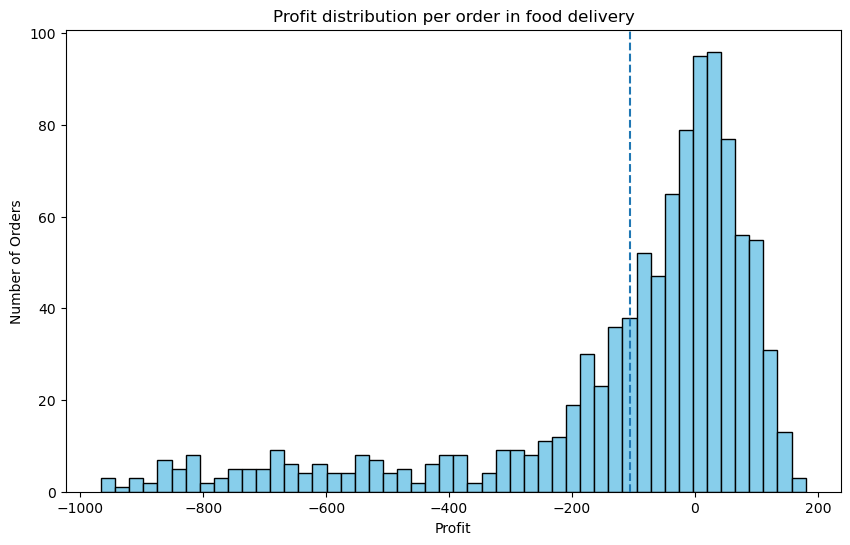

In [81]:
plt.figure(figsize=(10,6))
plt.hist(food_orders['Profit'],bins=50, color='skyblue', edgecolor = 'black')
plt.title('Profit distribution per order in food delivery')
plt.xlabel('Profit')
plt.ylabel('Number of Orders')
plt.axvline(food_orders['Profit'].mean(),linestyle = 'dashed')

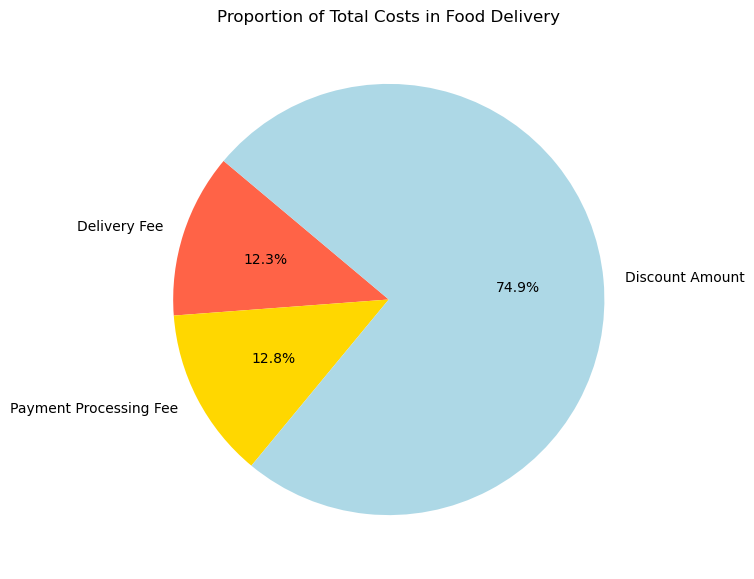

In [105]:
costs_breakdown = food_orders[['Delivery Fee','Payment Processing Fee', 'Discount Amount']].sum()
plt.figure(figsize=(7,7))
plt.pie(costs_breakdown,labels=costs_breakdown.index, autopct='%1.1f%%', startangle=140, colors=['tomato', 'gold', 'lightblue'])
plt.title('Proportion of Total Costs in Food Delivery')
plt.show()

In [87]:
costs_breakdown

Delivery Fee               28620.00
Payment Processing Fee     29832.00
Discount Amount           174257.85
dtype: float64

Text(0, 0.5, 'Amount(INR)')

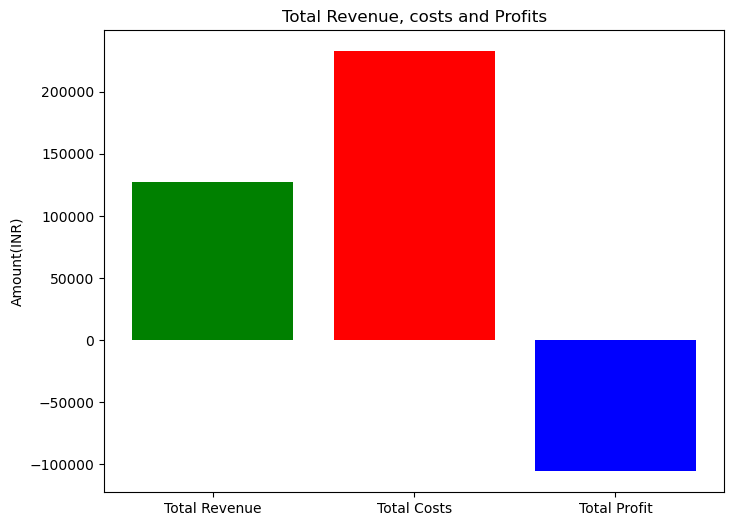

In [125]:
totals = ['Total Revenue','Total Costs','Total Profit']
values = [total_revenue,total_costs,total_profit]
plt.figure(figsize=(8,6))
plt.bar(totals,values, color=['green','red','blue'])
plt.title('Total Revenue, costs and Profits')
plt.ylabel('Amount(INR)')

In [212]:
# filter the dataset for profitable orders

In [127]:
profitable_orders = food_orders[food_orders['Profit']>0]

In [129]:
profitable_orders

,Order ID,Customer ID,Restaurant ID,Order Date and Time,Delivery Date and Time,Order Value,Delivery Fee,Payment Method,Discounts and Offers,Commission Fee,Payment Processing Fee,Refunds/Chargebacks,Discount Percentage,Discount Amount,Total Costs,Revenue,Profit
0,1,C8270,R2924,2024-02-01 01:11:52,2024-02-01 02:39:52,1914,0,Credit Card,5% on App,150,47,0,5.0,95.70,142.70,150,7.30
1,2,C1860,R2054,2024-02-02 22:11:04,2024-02-02 22:46:04,986,40,Digital Wallet,10%,198,23,0,10.0,98.60,161.60,198,36.40
3,4,C6191,R2642,2024-01-16 22:52:49,2024-01-16 23:38:49,1463,50,Cash on Delivery,None,146,27,0,0.0,0.00,77.00,146,69.00
5,6,C7265,R2777,2024-01-25 04:36:52,2024-01-25 05:27:52,439,20,Cash on Delivery,10%,92,27,150,10.0,43.90,90.90,92,1.10
6,7,C1466,R2457,2024-01-12 23:55:48,2024-01-13 00:48:48,303,30,Digital Wallet,5% on App,144,12,50,5.0,15.15,57.15,144,86.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988,989,C8311,R2380,2024-01-31 06:48:21,2024-01-31 08:43:21,1511,0,Credit Card,5% on App,136,10,0,5.0,75.55,85.55,136,50.45
989,990,C8186,R2622,2024-01-09 17:54:38,2024-01-09 18:42:38,1058,50,Credit Card,5% on App,182,45,0,5.0,52.90,147.90,182,34.10
995,996,C6232,R2129,2024-01-14 05:57:00,2024-01-14 06:39:00,825,0,Digital Wallet,5% on App,165,47,50,5.0,41.25,88.25,165,76.75
996,997,C6797,R2742,2024-01-28 08:50:43,2024-01-28 10:10:43,1627,50,Cash on Delivery,None,110,42,0,0.0,0.00,92.00,110,18.00


In [131]:
profitable_orders.shape

(415, 17)

In [133]:
profitable_orders.columns

Index(['Order ID', 'Customer ID', 'Restaurant ID', 'Order Date and Time',
       'Delivery Date and Time', 'Order Value', 'Delivery Fee',
       'Payment Method', 'Discounts and Offers', 'Commission Fee',
       'Payment Processing Fee', 'Refunds/Chargebacks', 'Discount Percentage',
       'Discount Amount', 'Total Costs', 'Revenue', 'Profit'],
      dtype='object')

In [214]:
# calculate the average commission percentage for profitable orders

In [143]:
profitable_orders['Commission Percentage'] = (profitable_orders['Commission Fee']/profitable_orders['Order Value'])*100

C:\Users\lenovo\AppData\Local\Temp\ipykernel_11624\3797490508.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profitable_orders['Commission Percentage'] = (profitable_orders['Commission Fee']/profitable_orders['Order Value'])*100


In [145]:
profitable_orders.columns

Index(['Order ID', 'Customer ID', 'Restaurant ID', 'Order Date and Time',
       'Delivery Date and Time', 'Order Value', 'Delivery Fee',
       'Payment Method', 'Discounts and Offers', 'Commission Fee',
       'Payment Processing Fee', 'Refunds/Chargebacks', 'Discount Percentage',
       'Discount Amount', 'Total Costs', 'Revenue', 'Profit',
       'Commission Percentage'],
      dtype='object')

In [149]:
profitable_orders[['Order Value','Commission Fee', 'Profit', 'Commission Percentage']]

,Order Value,Commission Fee,Profit,Commission Percentage
0,1914,150,7.30,7.836991
1,986,198,36.40,20.081136
3,1463,146,69.00,9.979494
5,439,92,1.10,20.956720
6,303,144,86.85,47.524752
...,...,...,...,...
988,1511,136,50.45,9.000662
989,1058,182,34.10,17.202268
995,825,165,76.75,20.000000
996,1627,110,18.00,6.760910


In [216]:
# calculate the average discount percentage for profitable orders

In [155]:
profitable_orders['Effective Discount Percentage'] = (profitable_orders['Discount Amount']/profitable_orders['Order Value'])*100

C:\Users\lenovo\AppData\Local\Temp\ipykernel_11624\967857031.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profitable_orders['Effective Discount Percentage'] = (profitable_orders['Discount Amount']/profitable_orders['Order Value'])*100


In [159]:
profitable_orders.columns

Index(['Order ID', 'Customer ID', 'Restaurant ID', 'Order Date and Time',
       'Delivery Date and Time', 'Order Value', 'Delivery Fee',
       'Payment Method', 'Discounts and Offers', 'Commission Fee',
       'Payment Processing Fee', 'Refunds/Chargebacks', 'Discount Percentage',
       'Discount Amount', 'Total Costs', 'Revenue', 'Profit',
       'Commission Percentage', 'Effective Discount Percentage'],
      dtype='object')

In [171]:
profitable_orders.iloc[:,[5,9,13,16,17,18]]

,Order Value,Commission Fee,Discount Amount,Profit,Commission Percentage,Effective Discount Percentage
0,1914,150,95.70,7.30,7.836991,5.0
1,986,198,98.60,36.40,20.081136,10.0
3,1463,146,0.00,69.00,9.979494,0.0
5,439,92,43.90,1.10,20.956720,10.0
6,303,144,15.15,86.85,47.524752,5.0
...,...,...,...,...,...,...
988,1511,136,75.55,50.45,9.000662,5.0
989,1058,182,52.90,34.10,17.202268,5.0
995,825,165,41.25,76.75,20.000000,5.0
996,1627,110,0.00,18.00,6.760910,0.0


In [218]:
# calculate the new averages

In [173]:
new_avg_commission_percentage = profitable_orders['Commission Percentage'].mean()
new_avg_discount_percentage = profitable_orders['Effective Discount Percentage'].mean()

In [175]:
print(new_avg_commission_percentage,new_avg_discount_percentage)

30.508436145149435 5.867469879518072


In [220]:
# simulate profitability with recommended discounts and commissions

In [177]:
recommended_commission_percentage = 30.0
recommended_discount_percentage = 6.0

In [222]:
# calculate the simulated commission fee and discount amount using recommended percentages

In [179]:
food_orders['Simulated commission fee'] = food_orders['Order Value']*(recommended_commission_percentage)/100

In [181]:
food_orders['Simulated discount amount'] = food_orders['Order Value']*(recommended_discount_percentage)/100

In [183]:
food_orders.columns

Index(['Order ID', 'Customer ID', 'Restaurant ID', 'Order Date and Time',
       'Delivery Date and Time', 'Order Value', 'Delivery Fee',
       'Payment Method', 'Discounts and Offers', 'Commission Fee',
       'Payment Processing Fee', 'Refunds/Chargebacks', 'Discount Percentage',
       'Discount Amount', 'Total Costs', 'Revenue', 'Profit',
       'Simulated commission fee', 'Simulated discount amount'],
      dtype='object')

In [224]:
# recalculate total costs and profit with simulated values

In [185]:
food_orders['simulated total costs'] = \
(food_orders['Delivery Fee']+food_orders['Payment Processing Fee']+\
 food_orders['Simulated discount amount'])

In [187]:
food_orders['simulated profit'] =\
(food_orders['Simulated commission fee']-\
 food_orders['simulated total costs'])

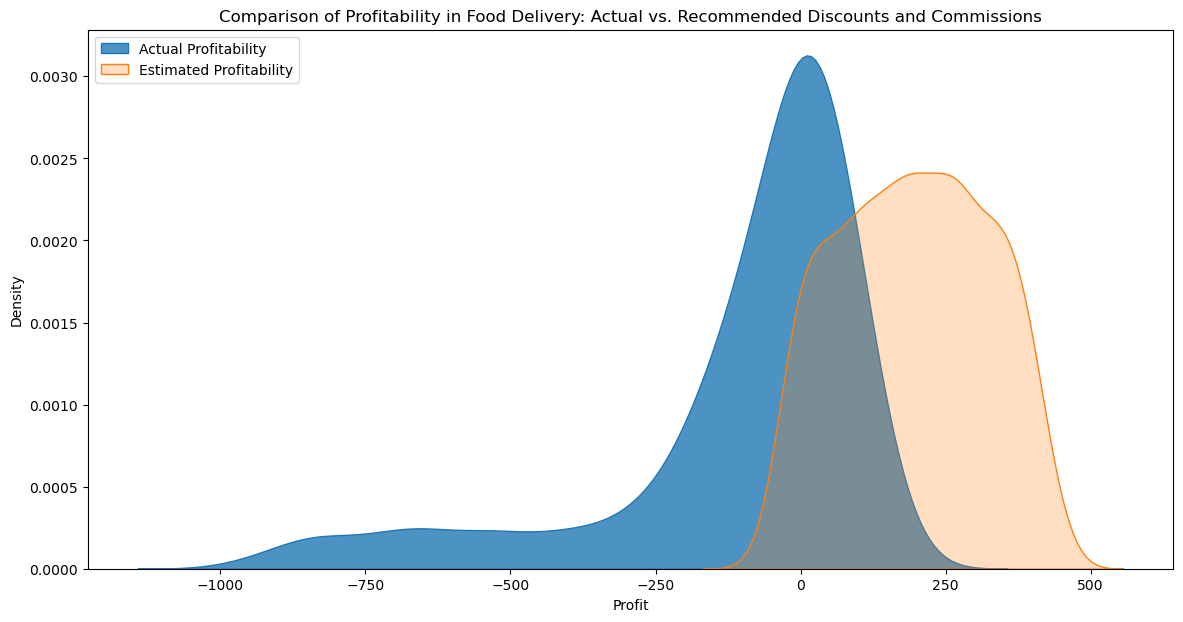

In [201]:
plt.figure(figsize=(14,7))
sns.kdeplot(food_orders['Profit'], label='Actual Profitability', fill=True, alpha=0.8)
sns.kdeplot(food_orders['simulated profit'], label='Estimated Profitability', fill=True)
plt.title('Comparison of Profitability in Food Delivery: Actual vs. Recommended Discounts and Commissions')
plt.xlabel('Profit')
plt.ylabel('Density')
plt.legend(loc='upper left')
plt.show()